In [5]:
!pip install pyLDAvis wordcloud gensim scipy

In [6]:
#Libraries 

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nltk
import spacy

# STEP 1: Choosing the Database

In this assignment we chose the Disneyland Review feeedback dataset. Looking at this dataset it is very clear that this is the data is broken down into 3 groups based on the locations being written about in the reviews.  

In [8]:
#Import the dataset

disneyland_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-a3-Sasson-Acosta\data\raw\DisneylandReviews.csv", header=0, encoding="latin-1")

In [9]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [10]:
#Documenting information about the rows and columns

#Store the number of rows in a variable
num_rows=len(disneyland_df)

#Print the clear number
print(f"There are {num_rows} in this dataset")

#2.1.2 Columns
disneyland_df.columns
#Column 1 ("Review_ID"): This column is made up of strings that are comprised of reviews
#Column 2 ("Rating"): This column is comprised of strings that either read positive or negative.
#Column 3 ("Year_Month"): This column is comprise of the date and month that the review is written in the format "YY-MM"
#Column 4 ("Reviewer_Location"): This column contains the location of the person writing the review
#Column 5 ("Review_Text"): This column contains the full reviews about the Disneyland location
#Column 6 ("Branch"): This column contains the park in which the review is written about


#2.1.3 Data Types
disneyland_df.dtypes
#Column 1 ("Review_ID"): Because this is a consistent value that cannot have mathematical operations done to it, I would classify this as a string
#Column 2 ("Rating"): This column very clearly is a numerical value that could be used in mathematical functions. This would be float.
#Column 3 ("Year_Month"): Right now it is a string, but it could be turned into a date type if we use a few functions to convert it.
#Column 4 ("Reviewer_Location"): This is a string.
#Column 5 ("Review_Text"): This is also a string.
#Column 6 ("Branch"): This is also a string. 

#2.1.4 Missing Values

#There are no missing values in this dataset.
disneyland_df.isna().sum()



There are 42656 in this dataset


Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

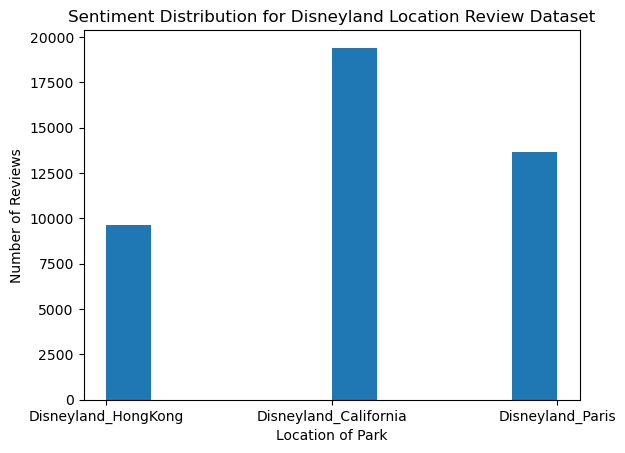

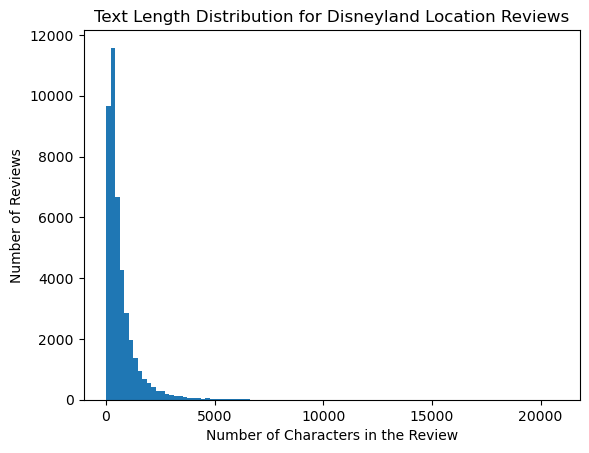

In [11]:
#2.2 Class Distribution

#Show a histogram for the distribution of the Sentiment reviews
plt.hist(disneyland_df['Branch'])
plt.xlabel("Location of Park")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution for Disneyland Location Review Dataset")
#Run this to save the figure as a .png file
#plt.savefig("location_distribution_hist.png")
plt.show()

#2.2.1 Is the dataset balanced?

#Shows a histogram for the length of the reviews in characters
#Finds the number of characters for each review and stores them in a variable
text_len_hist_data=disneyland_df["Review_Text"].str.len()
#Create the histogram with enough bins to show the distribution clearly
plt.hist(text_len_hist_data,bins=100)
plt.xlabel("Number of Characters in the Review")
plt.ylabel("Number of Reviews")
plt.title("Text Length Distribution for Disneyland Location Reviews")
#Run this to save the figure as a .png file
#plt.savefig("text_length_distribution_hist.png")
plt.show()

In [12]:
def most_popular_words(dataframe):
    words=dataframe['Review_Text'].str.split()
    all_words=words.explode()
    all_words_standard=all_words.str.lower()
    word_counts=all_words_standard.value_counts()
    top_n_words=word_counts.index[:10]
    return top_n_words

In [13]:
#Break Down the Different Categories
california_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_California']
hong_kong_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_HongKong']
paris_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_Paris']

print(f'The average number of characters in a review (before cleaning) is {disneyland_df['Review_Text'].str.len().mean()} characters.')
print(f'The average number of characters in a California review is {california_reviews['Review_Text'].str.len().mean()} characters.')
print(f'The average number of characters in a Paris review is {paris_reviews['Review_Text'].str.len().mean()} characters.')
print(f'The average number of characters in a Disneyland review is {hong_kong_reviews['Review_Text'].str.len().mean()} characters.')

#2.3.2 Vocabulary
#These reviews contain no emojis, more casual language, language that could be used to heighten emotion (contain emphasis). There are also certain cases where words
#are written in all caps. Depending on the person who wrote it there are some reviews that are more sopisticated in terms of word choice while other people used more 
#simple vocabulary. 

#2.3.3 Common words per class and label
print(f'The top 10 most popular words in California reviews are {', '.join(most_popular_words(california_reviews))}.')
print(f'The top 10 most popular words in Paris reviews are {', '.join(most_popular_words(paris_reviews))}.')
print(f'The top 10 most popular words in Hong Kong reviews are {', '.join(most_popular_words(hong_kong_reviews))}.')

The average number of characters in a review (before cleaning) is 696.8175403225806 characters.
The average number of characters in a California review is 618.5775533340204 characters.
The average number of characters in a Paris review is 909.370139398386 characters.
The average number of characters in a Disneyland review is 553.4945945945946 characters.
The top 10 most popular words in California reviews are the, and, to, a, we, of, in, was, for, i.
The top 10 most popular words in Paris reviews are the, and, to, a, of, we, in, was, for, is.
The top 10 most popular words in Hong Kong reviews are the, and, to, a, is, of, in, was, for, we.


In [14]:
print(f'The number of reviews (documents) relating to Disneyland California is {disneyland_df['Branch'].value_counts()[0]}.')
print(f'The number of reviews (documents) relating to Disneyland Paris is {disneyland_df['Branch'].value_counts()[1]}.')
print(f'The number of reviews (documents) relating to Disneyland Hong Kong is {disneyland_df['Branch'].value_counts()[2]}.')

The number of reviews (documents) relating to Disneyland California is 19406.
The number of reviews (documents) relating to Disneyland Paris is 13630.
The number of reviews (documents) relating to Disneyland Hong Kong is 9620.


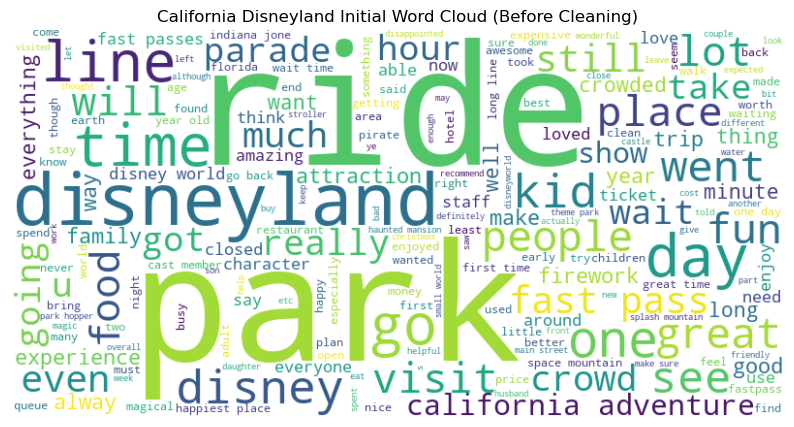

In [15]:
from wordcloud import WordCloud, STOPWORDS

text_combined = " ".join(california_reviews['Review_Text'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('California Disneyland Initial Word Cloud (Before Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

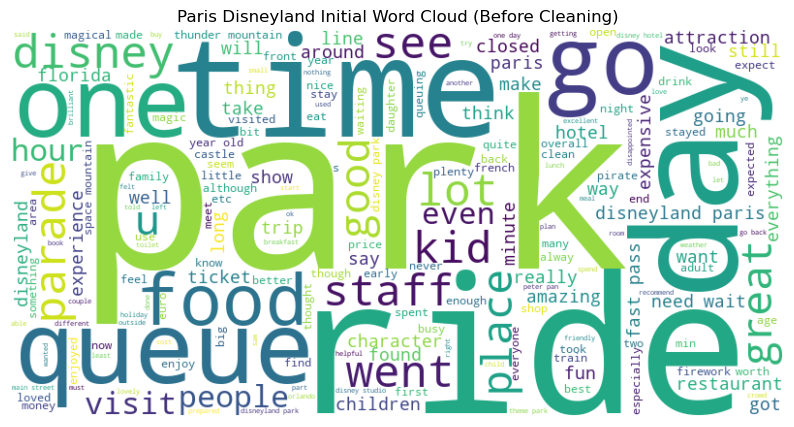

In [16]:
text_combined = " ".join(paris_reviews['Review_Text'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('Paris Disneyland Initial Word Cloud (Before Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

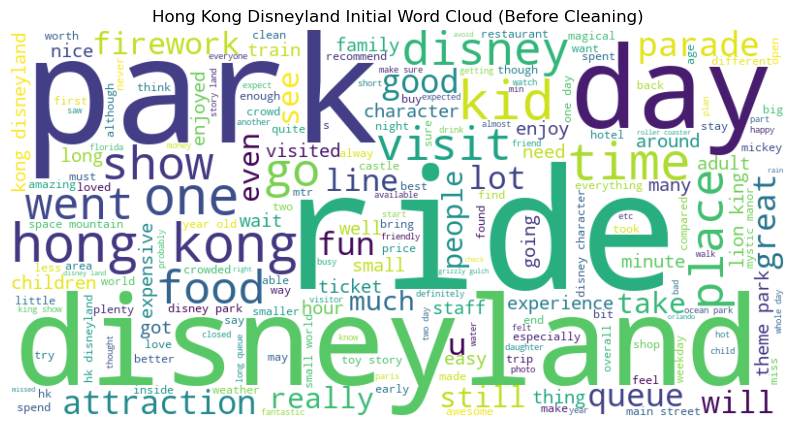

In [17]:
text_combined = " ".join(hong_kong_reviews['Review_Text'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('Hong Kong Disneyland Initial Word Cloud (Before Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [18]:
# Vocabulary for each group
text_combined_hong_kong = " ".join(hong_kong_reviews['Review_Text'].dropna().str.lower())
text_combined_paris = " ".join(paris_reviews['Review_Text'].dropna().str.lower())
text_combined_california = " ".join(california_reviews['Review_Text'].dropna().str.lower())

individual_words_hong_kong=text_combined_hong_kong.split()
individual_words_paris=text_combined_paris.split()
individual_words_california=text_combined_california.split()


# Get the unique words (vocabulary) using a set
vocabulary_hong_kong = set(individual_words_hong_kong)
vocabulary_paris = set(individual_words_paris)
vocabulary_california = set(individual_words_california)


print("Vocabulary Hong Kong:", vocabulary_hong_kong, '\n')
print("Vocabulary Paris:", vocabulary_paris, '\n')
print("Vocabulary California:", vocabulary_california, '\n')

Vocabulary Hong Kong: {'concept', 'stitch:', 'romantic', 'little)', 'eateries', 'fiasco!!!', 'section,', 'bringin', 'peoples', '(ive', "weren't.", 'onto', 'again.geyser', 'inspiring.try', 'condition,so,', 'complimentary', 'around...your', 'dissapointed.', 'everywhere.the', 'bin,', 'hats.3.', 'university,', 'rider).', 'sunnybay', 'peso', "have'nt", 'it!', 'vitamin', 'swifter', 'wonderful.staffs', "donald's", 'issue!', 'cab.', 'bcos', 'hidden', 'extensions', 'tipping', 'unleashing', 'potty', 'pole.mad', 'child.', 'display!!!', 'indeed,', 'dark)', 'do.get', 'enitre', 'slightest', 'people!hong', 'fantasies', 'heavy).', 'musicals,', '8.15pm', 'back&forth', 'everyday', 'immediately.what', 'highlands,universal', 'access.i', 'couples', 'often).', '(2', 'worths', 'fractured', 'complex.', '28th', 'resonable', 'fastpass.', 'lamb', 'pride', 'first.mystic', 'weds', "'magical'", 'rainwear.', 'attractionswe', 'fantastically', 'anything.most', 'outside...', 'lbs', 'cover', 'try:.', 'cny,', 'picnics,',

In [36]:
print(f'The Hong Kong Vocabulary before cleaning contains {len(vocabulary_hong_kong)} words')
print(f'The Paris Vocabulary before cleaning contains {len(vocabulary_paris)} words')
print(f'The California Vocabulary before cleaning contains {len(vocabulary_california)} words')

The Hong Kong Vocabulary before cleaning contains 40860 words
The Paris Vocabulary before cleaning contains 75531 words
The California Vocabulary before cleaning contains 64394 words


In [20]:
# Store the dataframe variable so we can use it in the exact same state in the next notebook
%store disneyland_df

Stored 'disneyland_df' (DataFrame)
